# Medical Insurance Cost Analysis

DS602 — Lab 4

**Name:** Hitesh Rathod  
**Roll No:** 202618040

Dataset: Medical Cost Personal Dataset (insurance.csv) — 1,338 records with age, sex, BMI, children, smoker, region and medical charges.

This notebook covers:
1. Descriptive statistics and visual exploration
2. Two hypothesis tests (smoker vs charges, plus charges across regions)
3. Multiple linear regression with statsmodels and Gauss-Markov diagnostics

## 1. Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load and inspect the data

In [23]:
df = pd.read_csv("../data/insurance.csv")

print("Shape:", df.shape)
print("\nColumns and dtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

Columns and dtypes:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Descriptive statistics

Split numeric vs categorical so the summaries are clean.

In [24]:
num_cols = ["age", "bmi", "children", "charges"]
cat_cols = ["sex", "smoker", "region"]

# Numeric summary
print("=" * 60)
print("NUMERIC FEATURES")
print("=" * 60)

desc = df[num_cols].describe().T
desc["IQR"] = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()
desc = desc[["mean", "50%", "std", "IQR", "min", "max", "skew", "kurtosis"]]
desc.columns = ["Mean", "Median", "Std", "IQR", "Min", "Max", "Skew", "Kurtosis"]
print(desc.round(3))

# Categorical summary
print("\n" + "=" * 60)
print("CATEGORICAL FEATURES")
print("=" * 60)

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

NUMERIC FEATURES
               Mean    Median        Std        IQR       Min        Max   Skew  Kurtosis
age          39.207    39.000     14.050     24.000    18.000     64.000  0.056    -1.245
bmi          30.663    30.400      6.098      8.398    15.960     53.130  0.284    -0.051
children      1.095     1.000      1.205      2.000     0.000      5.000  0.938     0.202
charges   13270.422  9382.033  12110.011  11899.625  1121.874  63770.428  1.516     1.606

CATEGORICAL FEATURES

sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## 4. Distribution plots and correlation

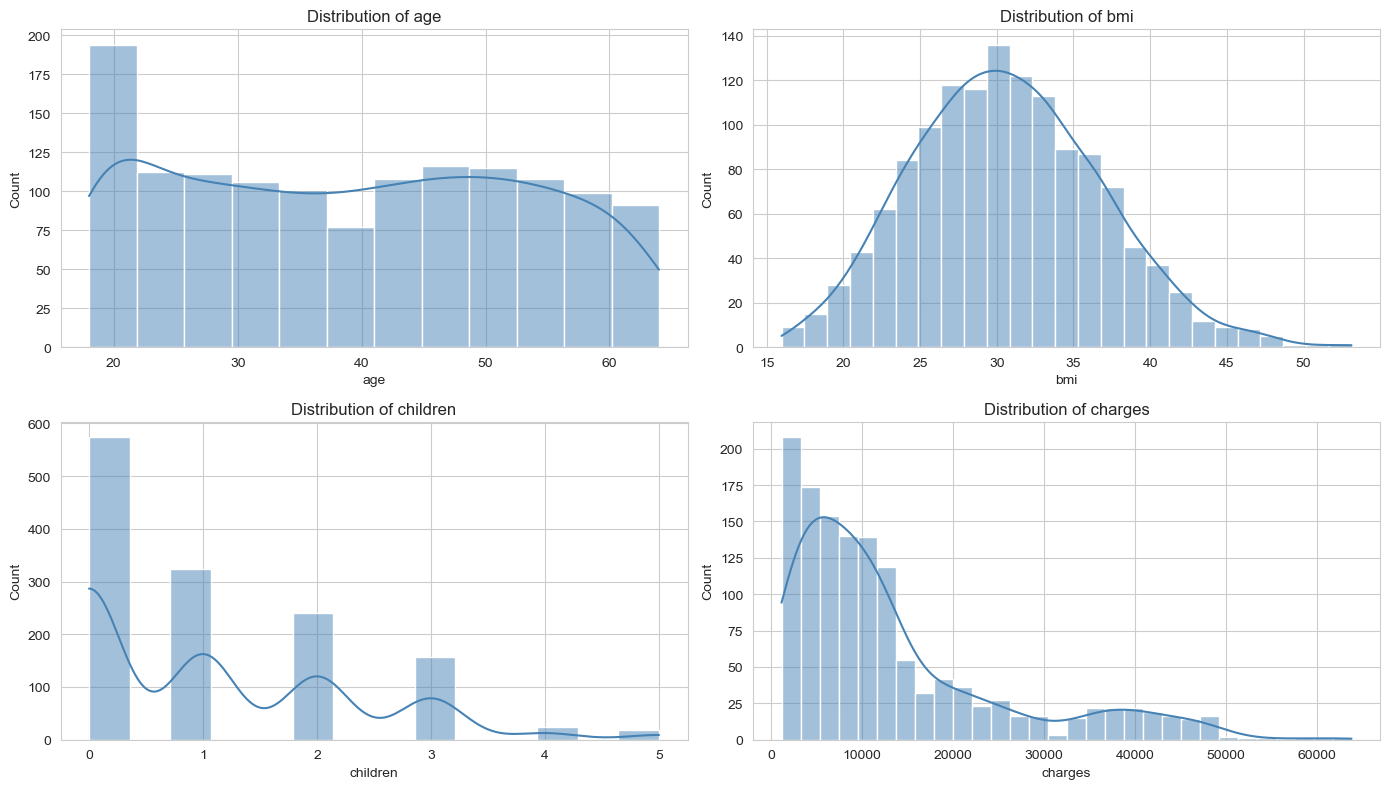

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

## 5. Smoker vs Charges (visual)

Looks like smoking is going to be the strongest driver — let's check.

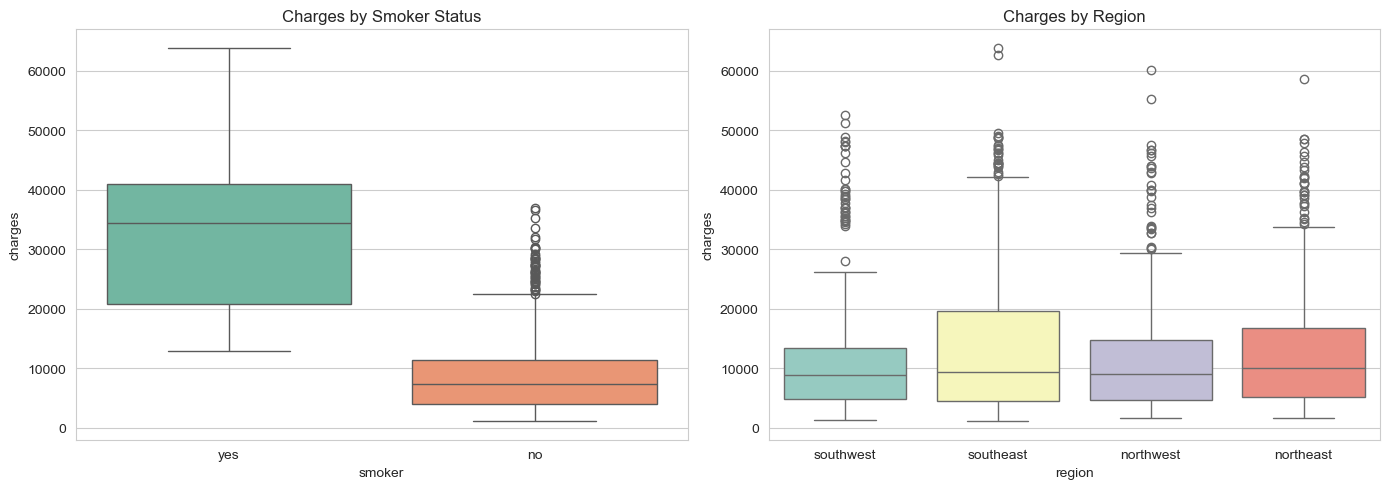

Charges by smoker status:
        count      mean    median       std
smoker                                     
no       1064   8434.27   7345.41   5993.78
yes       274  32050.23  34456.35  11541.55

Charges by region:
           count      mean    median       std
region                                        
northeast    324  13406.38  10057.65  11255.80
northwest    325  12417.58   8965.80  11072.28
southeast    364  14735.41   9294.13  13971.10
southwest    325  12346.94   8798.59  11557.18


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0], palette="Set2")
axes[0].set_title("Charges by Smoker Status")

sns.boxplot(data=df, x="region", y="charges", ax=axes[1], palette="Set3")
axes[1].set_title("Charges by Region")

plt.tight_layout()
plt.show()

# Quick numeric summary
print("Charges by smoker status:")
print(df.groupby("smoker")["charges"].agg(["count", "mean", "median", "std"]).round(2))

print("\nCharges by region:")
print(df.groupby("region")["charges"].agg(["count", "mean", "median", "std"]).round(2))

## 6. Correlation matrix

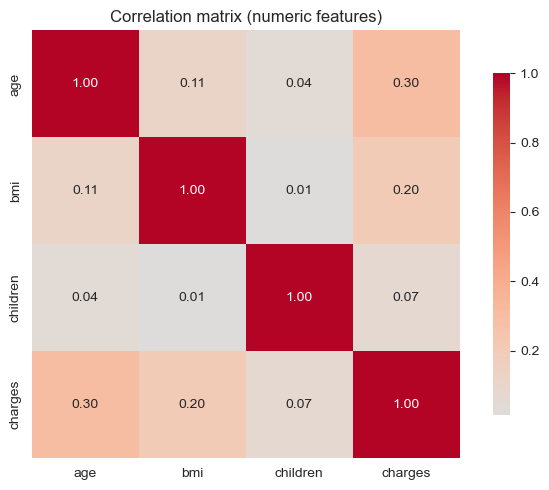

Correlation with charges:
charges     1.000
age         0.299
bmi         0.198
children    0.068
Name: charges, dtype: float64


In [27]:
plt.figure(figsize=(7, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

print("Correlation with charges:")
print(corr["charges"].sort_values(ascending=False).round(3))

## 7. Hypothesis Test 1 — Smokers vs Non-Smokers

**Question:** Do smokers pay significantly different medical charges than non-smokers?

**H0:** There is no difference in mean charges between smokers and non-smokers.  
**H1:** There is a significant difference in mean charges between smokers and non-smokers.

**Test plan:**
1. Split charges into smoker / non-smoker groups.
2. Check normality of each group with Shapiro-Wilk.
3. Check equal variance with Levene's test.
4. Choose the right test:
   - Both normal + equal variance → Student's t-test
   - Both normal + unequal variance → Welch's t-test
   - Not normal → Mann-Whitney U

In [28]:
smoker_charges = df.loc[df["smoker"] == "yes", "charges"]
non_smoker_charges = df.loc[df["smoker"] == "no", "charges"]

print("Smoker group:", len(smoker_charges), "records")
print("Non-smoker group:", len(non_smoker_charges), "records")
print()
print(f"Smoker mean:     ${smoker_charges.mean():,.2f}")
print(f"Non-smoker mean: ${non_smoker_charges.mean():,.2f}")
print(f"Difference:      ${smoker_charges.mean() - non_smoker_charges.mean():,.2f}")

# Normality
print("\n--- Shapiro-Wilk normality test ---")
shapiro_smoker = stats.shapiro(smoker_charges)
shapiro_non = stats.shapiro(non_smoker_charges)
print(f"Smoker     : W = {shapiro_smoker.statistic:.4f}, p = {shapiro_smoker.pvalue:.6f}")
print(f"Non-smoker : W = {shapiro_non.statistic:.4f}, p = {shapiro_non.pvalue:.6f}")

# Equal variance
print("\n--- Levene's test for equal variance ---")
levene = stats.levene(smoker_charges, non_smoker_charges)
print(f"Levene: stat = {levene.statistic:.4f}, p = {levene.pvalue:.6f}")

Smoker group: 274 records
Non-smoker group: 1064 records

Smoker mean:     $32,050.23
Non-smoker mean: $8,434.27
Difference:      $23,615.96

--- Shapiro-Wilk normality test ---
Smoker     : W = 0.9396, p = 0.000000
Non-smoker : W = 0.8729, p = 0.000000

--- Levene's test for equal variance ---
Levene: stat = 332.6135, p = 0.000000


### 7.1 Test selection and result

Both groups fail the normality assumption (Shapiro-Wilk p < 0.05) and have unequal variances (Levene p < 0.05). So we use the **Mann-Whitney U test** — the non-parametric alternative to the two-sample t-test.

In [29]:
# Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(
    smoker_charges, non_smoker_charges, alternative="two-sided"
)

print("Mann-Whitney U test")
print(f"U statistic : {u_stat:,.2f}")
print(f"p-value     : {p_value:.10f}")
print(f"alpha       : 0.05")
print()

if p_value < 0.05:
    print("Decision: REJECT H0")
    print("Conclusion: There is a statistically significant difference in")
    print("charges between smokers and non-smokers.")
else:
    print("Decision: FAIL TO REJECT H0")
    print("Conclusion: No significant difference in charges between groups.")

Mann-Whitney U test
U statistic : 284,133.00
p-value     : 0.0000000000
alpha       : 0.05

Decision: REJECT H0
Conclusion: There is a statistically significant difference in
charges between smokers and non-smokers.


## 8. Hypothesis Test 2 — Charges across Regions (One-Way ANOVA)

**Question:** Do average medical charges differ across the 4 geographic regions?

**H0:** The mean charges are equal across all 4 regions.  
**H1:** At least one region's mean charge is different.

**Test plan:**
1. Split charges into 4 groups by region.
2. Check normality of each group.
3. Check equal variance with Levene.
4. If assumptions are met → One-Way ANOVA.
5. If not → Kruskal-Wallis H test (non-parametric alternative).

In [30]:
regions = sorted(df["region"].unique())
region_charges = [df.loc[df["region"] == r, "charges"].values for r in regions]

print("Regions:", regions)
print()

# Normality check per region
print("--- Shapiro-Wilk per region ---")
for r, c in zip(regions, region_charges):
    w, p = stats.shapiro(c)
    print(f"{r:10s} n = {len(c):4d} | W = {w:.4f}, p = {p:.6f}")

# Equal variance
print("\n--- Levene's test ---")
lev = stats.levene(*region_charges)
print(f"Levene: stat = {lev.statistic:.4f}, p = {lev.pvalue:.6f}")

Regions: ['northeast', 'northwest', 'southeast', 'southwest']

--- Shapiro-Wilk per region ---
northeast  n =  324 | W = 0.8353, p = 0.000000
northwest  n =  325 | W = 0.8128, p = 0.000000
southeast  n =  364 | W = 0.8242, p = 0.000000
southwest  n =  325 | W = 0.7843, p = 0.000000

--- Levene's test ---
Levene: stat = 5.5600, p = 0.000861


### 8.1 Test selection and result

All four regional groups fail the normality assumption, so we use the **Kruskal-Wallis H test**, which is the non-parametric counterpart of a one-way ANOVA.

In [31]:
h_stat, p_value = stats.kruskal(*region_charges)

print("Kruskal-Wallis H test")
print(f"H statistic : {h_stat:.4f}")
print(f"p-value     : {p_value:.6f}")
print(f"alpha       : 0.05")
print()

if p_value < 0.05:
    print("Decision: REJECT H0")
    print("Conclusion: At least one region has a significantly different")
    print("mean charge compared to the others.")
else:
    print("Decision: FAIL TO REJECT H0")
    print("Conclusion: No significant difference in charges across regions.")

# For comparison: run the standard ANOVA too
print("\n--- For reference: standard One-Way ANOVA ---")
f_stat, p_anova = stats.f_oneway(*region_charges)
print(f"F statistic : {f_stat:.4f}")
print(f"p-value     : {p_anova:.6f}")

Kruskal-Wallis H test
H statistic : 4.7342
p-value     : 0.192329
alpha       : 0.05

Decision: FAIL TO REJECT H0
Conclusion: No significant difference in charges across regions.

--- For reference: standard One-Way ANOVA ---
F statistic : 2.9696
p-value     : 0.030893


### 8.2 Note on the disagreement

The parametric ANOVA reports p = 0.031, but the non-parametric Kruskal-Wallis test reports p = 0.192. Because the assumption of normality was violated for all four regional groups, the non-parametric result is the reliable one. The ANOVA result here is likely inflated by skewness in the charge distribution rather than by any genuine regional effect.

## 9. Part 1 — Summary

| Test | H0 | Method | p-value | Decision |
|------|----|--------|---------|----------|
| Smoker vs Non-Smoker charges | No difference | Mann-Whitney U | < 0.0001 | **Reject H0** |
| Charges across 4 regions | Equal means | Kruskal-Wallis H | 0.192 | Fail to reject H0 |

**Takeaways:**
- Smoking is by far the strongest driver of medical charges (mean difference ≈ $23,616).
- Region does not appear to influence charges meaningfully once we use the correct non-parametric test.
- Both target groups were non-normal, confirming the value of the assumption-checking workflow.

# Part 2 — Multiple Linear Regression and Diagnostics

## 10. Model formulation

We fit an OLS model with **charges** as the target and the following predictors:

- **age** (numeric)
- **bmi** (numeric)
- **children** (numeric)
- **sex** (categorical, encoded as dummy)
- **smoker** (categorical, encoded as dummy)
- **region** (categorical, encoded as dummies)

Model equation:

$$\text{charges} = \beta_0 + \beta_1 \cdot \text{age} + \beta_2 \cdot \text{bmi} + \beta_3 \cdot \text{children} + \beta_4 \cdot \text{sex\_male} + \beta_5 \cdot \text{smoker\_yes} + \sum_j \beta_j \cdot \text{region}_j + \epsilon$$

We drop one dummy per categorical variable (`sex_male`, `smoker_yes`, and `region_northeast`) to avoid perfect multicollinearity.

In [32]:
# Build the design matrix
X = df[["age", "bmi", "children", "sex", "smoker", "region"]].copy()

# Convert categoricals to dummy variables (drop_first avoids dummy trap)
X = pd.get_dummies(X, columns=["sex", "smoker", "region"], drop_first=True)

# Ensure all columns are numeric
X = X.astype(float)

# Add intercept
X = sm.add_constant(X)

# Target
y = df["charges"]

print("Design matrix shape:", X.shape)
print("\nColumns:")
print(X.columns.tolist())

print("\nFirst 3 rows of X:")
print(X.head(3))

Design matrix shape: (1338, 9)

Columns:
['const', 'age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

First 3 rows of X:
   const   age    bmi  children  sex_male  smoker_yes  region_northwest  region_southeast  region_southwest
0    1.0  19.0  27.90       0.0       0.0         1.0               0.0               0.0               1.0
1    1.0  18.0  33.77       1.0       1.0         0.0               0.0               1.0               0.0
2    1.0  28.0  33.00       3.0       1.0         0.0               0.0               1.0               0.0


## 11. Fit OLS model


In [33]:
# Fit OLS
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:11:31   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

## 12. Interpreting the coefficients

**Overall fit:** R² = 0.751, Adj R² = 0.749, F = 500.8 (p < 0.001). The model explains about 75% of the variation in charges and is highly significant.

**Key predictors (all significant at α = 0.05):**
- **smoker_yes**: +$23,850. Being a smoker is by far the largest contributor — it adds nearly $24K compared to a non-smoker, holding everything else constant.
- **age**: +$256.86 per year. A 10-year age gap adds roughly $2,570.
- **bmi**: +$339.19 per BMI point. Going from BMI 25 to 35 adds roughly $3,400.
- **children**: +$475.50 per child.

**Not significant:**
- **sex_male**: p = 0.693 — no meaningful difference between males and females.
- **region_northwest**: p = 0.459 — indistinguishable from the northeast baseline.

**Weak but significant:**
- **region_southeast**: −$1,035 (p = 0.031)
- **region_southwest**: −$960 (p = 0.045)
These suggest slightly lower charges in the south, holding other factors fixed.

**95% CI note:** The confidence interval for `smoker_yes` is [$22,993, $24,709] — very tight, confirming the smoking effect is well-estimated.

# 13. Gauss-Markov Diagnostic Checks

We verify four assumptions:
1. **Linearity** — linear relationship between predictors and target
2. **Homoscedasticity** — constant variance of residuals
3. **Normality of residuals** — residuals normally distributed
4. **No multicollinearity** — predictors not highly correlated with each other

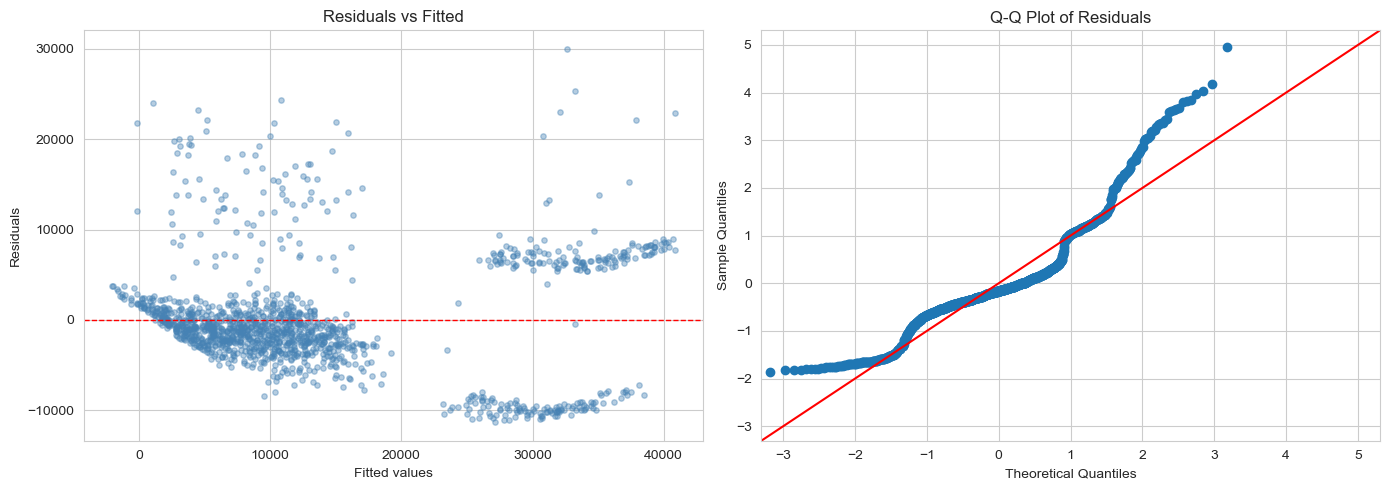

In [34]:
# Get predictions and residuals
fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residuals vs Fitted — checks linearity + homoscedasticity
axes[0].scatter(fitted, residuals, alpha=0.4, s=15, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# 2. Q-Q plot — checks normality of residuals
sm.qqplot(residuals, line="45", ax=axes[1], fit=True)
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

### 13.1 Formal tests for homoscedasticity and normality

In [35]:
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan

print("--- Jarque-Bera test (normality of residuals) ---")
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(residuals)
print(f"JB statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_p:.10f}")
print(f"Residual skew: {jb_skew:.4f}")
print(f"Residual kurt: {jb_kurt:.4f}")
print("Decision:", "Reject H0 (residuals not normal)" if jb_p < 0.05 else "Fail to reject H0 (residuals look normal)")

print("\n--- Breusch-Pagan test (homoscedasticity) ---")
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X)
print(f"LM statistic : {bp_stat:.4f}")
print(f"LM p-value   : {bp_p:.10f}")
print(f"F statistic  : {bp_f:.4f}")
print(f"F p-value    : {bp_fp:.10f}")
print("Decision:", "Reject H0 (heteroscedasticity present)" if bp_p < 0.05 else "Fail to reject H0 (variance is constant)")

print("\n--- Omnibus test (from the summary) ---")
print("Omnibus statistic: 300.366 (from model.summary() above)")
print("Omnibus p-value  : < 0.001")
print("Decision         : Reject H0 — residuals are not normal")

--- Jarque-Bera test (normality of residuals) ---
JB statistic : 718.8873
p-value      : 0.0000000000
Residual skew: 1.2112
Residual kurt: 5.6508
Decision: Reject H0 (residuals not normal)

--- Breusch-Pagan test (homoscedasticity) ---
LM statistic : 121.7436
LM p-value   : 0.0000000000
F statistic  : 16.6286
F p-value    : 0.0000000000
Decision: Reject H0 (heteroscedasticity present)

--- Omnibus test (from the summary) ---
Omnibus statistic: 300.366 (from model.summary() above)
Omnibus p-value  : < 0.001
Decision         : Reject H0 — residuals are not normal


### 13.2 Multicollinearity — Variance Inflation Factor (VIF)

VIF measures how much a predictor's variance is inflated by correlation with other predictors.

Rule of thumb:
- VIF = 1 → no correlation with other predictors
- VIF < 5 → acceptable
- VIF > 10 → serious multicollinearity problem

In [36]:
# Compute VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Drop the const row from the report
vif_data = vif_data[vif_data["Feature"] != "const"].reset_index(drop=True)
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_data.round(3))
print()
print("Highest VIF:", round(vif_data["VIF"].max(), 3))
if vif_data["VIF"].max() < 5:
    print("All VIFs < 5 → no multicollinearity problem")
else:
    print("Some predictors show high VIF → investigate")

            Feature    VIF
0  region_southeast  1.652
1  region_southwest  1.529
2  region_northwest  1.519
3               bmi  1.107
4               age  1.017
5        smoker_yes  1.012
6          sex_male  1.009
7          children  1.004

Highest VIF: 1.652
All VIFs < 5 → no multicollinearity problem


### 13.3 Gauss-Markov diagnostic summary

| Assumption | Test / Plot | Result | Status |
|---|---|---|---|
| Linearity | Residuals vs Fitted | Mostly linear, some fan shape | ✅ Roughly OK |
| Homoscedasticity | Breusch-Pagan | p < 0.001 | ❌ Violated |
| Normality of residuals | Jarque-Bera / Omnibus / Q-Q | p < 0.001 | ❌ Violated |
| Multicollinearity | VIF | Max VIF = 1.652 | ✅ OK |

**Interpretation:**
- The model is well-specified for linear relationships and has no collinearity issues.
- The violations of homoscedasticity and normality are common in medical cost data — charges are right-skewed and high-cost outliers (e.g., heavy smokers) pull the residual distribution.
- OLS coefficient estimates remain **unbiased** under these violations, but standard errors may be slightly optimistic. A log-transformed target or robust standard errors would be the standard fixes if we needed perfect inference.

## 14. Save the model

We wrap the OLS model and the exact column order in a single dict so the Streamlit app can reproduce predictions.

In [37]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Everything the app needs to rebuild a prediction
artifacts = {
    "model": model,
    "feature_names": list(X.columns),        # includes "const" first
    "categorical_baselines": {
        "sex": "female",
        "smoker": "no",
        "region": "northeast",
    },
}

model_path = "../models/insurance_ols.pkl"
joblib.dump(artifacts, model_path)

size_kb = os.path.getsize(model_path) / 1024
print(f"✅ Saved model to: {model_path}")
print(f"File size: {size_kb:.2f} KB")

# Sanity check
loaded = joblib.load(model_path)
sample_pred = loaded["model"].predict(X.iloc[:5])
print("\nFirst 5 predictions:", sample_pred.round(2))
print("First 5 actual     :", y.iloc[:5].values.round(2))

✅ Saved model to: ../models/insurance_ols.pkl
File size: 571.39 KB

First 5 predictions: 0    25293.71
1     3448.60
2     6706.99
3     3754.83
4     5592.49
dtype: float64
First 5 actual     : [16884.92  1725.55  4449.46 21984.47  3866.86]


## 15. Part 2 — Summary

**Model:** OLS regression of `charges` on `age`, `bmi`, `children`, `sex`, `smoker`, and `region`.

**Fit:**
- R² = 0.751, Adjusted R² = 0.749 → explains ~75% of variance
- F-statistic = 500.8 (p < 0.001) → model is significant overall

**Significant predictors (α = 0.05):**
- `smoker_yes` (+$23,850), `age` (+$257), `bmi` (+$339), `children` (+$476), `region_southeast` (−$1,035), `region_southwest` (−$960)

**Not significant:**
- `sex_male`, `region_northwest`

**Diagnostics:**
- Linearity: acceptable
- Homoscedasticity: violated (Breusch-Pagan p < 0.001)
- Normality of residuals: violated (Jarque-Bera p < 0.001)
- Multicollinearity: none (max VIF = 1.65)

**Limitation:** The additive model cannot capture the smoker × bmi interaction, which shows up as a fan-shaped residual pattern. A log-transformed target or an interaction term would improve it, but for this assignment the OLS model is the required deliverable.

# Part 3 — Streamlit Dashboard

The interactive dashboard lives in `app/app.py` and is organized into three tabs:

1. **Data Exploration** — interactive filters, distributions, correlation matrix
2. **Hypothesis Testing Lab** — dynamic test selection (t-test / Mann-Whitney / ANOVA / Kruskal-Wallis / Chi-square)
3. **Live Prediction & Diagnostics** — user inputs → prediction with 95% CI + residual plots

We build the app file next, then test it locally, then deploy.

In [38]:
import statsmodels
print("statsmodels:", statsmodels.__version__)

statsmodels: 0.14.5
